# 200. BERT로 텍스트 분류 - 영문

이 튜토리얼에는 일반 텍스트 IMDB 영화 리뷰 데이터 세트에 대한 감정 분석을 수행하기 위해 BERT를 미세 조정하는 완전한 코드가 포함되어 있습니다.
모델을 훈련하는 것 외에도 텍스트를 적절한 형식으로 사전 처리하는 방법을 배우게 됩니다.

이 노트북에서 수행할 작업은 다음과 같습니다.

1. IMDB 데이터셋 불러오기
2. TensorFlow Hub에서 BERT 모델 로드
3. BERT와 분류기를 결합하여 나만의 모델 구축
4. 자신의 모델을 훈련하고 그 일환으로 BERT를 미세 조정합니다.
5. 모델을 저장하고 문장 분류에 사용

IMDB 데이터셋을 처음 사용하는 경우 자세한 내용은 [기본 텍스트 분류](https://www.tensorflow.org/tutorials/keras/text_classification)를 참조하세요.

In [1]:
# A dependency of the preprocessing for BERT inputs
!pip install -q -U tensorflow-text
!pip install -q tf-models-official

In [2]:
import os
import shutil

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization  # to create AdamW optimizer

import matplotlib.pyplot as plt

## Sentiment analysis

이 노트북은 감정 분석 모델을 훈련하여 리뷰 텍스트를 기반으로 영화 리뷰를 *긍정* 또는 *부정*으로 분류합니다.

### Download the IMDB dataset


In [3]:
url = 'https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'

dataset = tf.keras.utils.get_file('aclImdb_v1.tar.gz', url,
                            untar=True, cache_dir='.', cache_subdir='')

dataset_dir = os.path.join(os.path.dirname(dataset), 'aclImdb')

train_dir = os.path.join(dataset_dir, 'train')

# remove unused folders to make it easier to load the data
remove_dir = os.path.join(train_dir, 'unsup')
shutil.rmtree(remove_dir)

다음으로 `text_dataset_from_directory` 유틸리티를 사용하여 레이블이 지정된 `tf.data.Dataset`을 생성합니다.

IMDB 데이터셋은 이미 train 과 test로 나누어져 있지만 validation 세트가 부족합니다. 아래의 `validation_split` parameter를 사용하여 train 데이터를 80:20으로 분할하여 validation 세트를 생성합니다.

참고: `validation_split` 및 `subset` 인수를 사용할 때 validation 및 train 분할이 겹치지 않도록 임의의 seed를 지정하거나 `shuffle=False`를 전달해야 합니다.

In [4]:
AUTOTUNE = tf.data.AUTOTUNE
batch_size = 32
seed = 42

raw_train_ds = tf.keras.preprocessing.text_dataset_from_directory(
    'aclImdb/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='training',
    seed=seed)

class_names = raw_train_ds.class_names
train_ds = raw_train_ds.cache().prefetch(buffer_size=AUTOTUNE)

val_ds = tf.keras.preprocessing.text_dataset_from_directory(
    'aclImdb/train',
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation',
    seed=seed)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = tf.keras.preprocessing.text_dataset_from_directory(
    'aclImdb/test',
    batch_size=batch_size)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


몇 가지 리뷰를 살펴봅니다.

In [5]:
for text_batch, label_batch in train_ds.take(1):
  for i in range(3):
    print(f'Review: {text_batch.numpy()[i]}')
    label = label_batch.numpy()[i]
    print(f'Label : {label} ({class_names[label]})')

Review: b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell you, I love comedies. Especially comedy spoofs. "Airplane", "The Naked Gun" trilogy, "Blazing Saddles", "High Anxiety", and "Spaceballs" are some of my favorite comedies that spoof a particular genre. "Pandemonium" is not up there with those films. Most of the scenes in this movie had me sitting there in stunned silence because the movie wasn\'t all that funny. There are a few laughs in the film, but when you watch a comedy, you expect to laugh a lot more than a few times and that\'s all this film has going for it. Geez, "Scream" had more laughs than this film and that was more of a horror film. How bizarre is that?<br /><br />*1/2 (out of four)'
Label : 0 (neg)
Review: b"David Mamet is a very interesting and a very un-equal director. His first movie 'House of Games' was the one I liked best, and it set a series of films with characters whose perspective of life changes as they

## TensorFlow Hub에서 모델 로드

TensorFlow Hub에서 로드하고 미세 조정할 여러 BERT 모델을 선택할 수 있습니다. 

  - [BERT-Base](https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3), [Uncased](https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3) 원래 BERT 작성자가 발표한 가중치.  
  - [Small BERTs](https://tfhub.dev/google/collections/bert/1)는 동일한 일반 아키텍처를 갖지만 더 적거나 더 작은 Transformer 블록을 사용하므로 속도, 크기 및 품질 간의 균형을 모색.
  - [ALBERT](https://tfhub.dev/google/collections/albert/1): 레이어 간에 매개변수를 공유하여 모델 크기(하지만 계산 시간은 아님)를 줄이는 4가지 크기의 "A Lite BERT".
  - [BERT Experts](https://tfhub.dev/google/collections/experts/bert/1): 모두 BERT 기반 아키텍처를 가지고 있지만 모델 목표 task 에 더 밀접하게 정렬하기 위해 8가지  서로 다른 사전 교육 도메인의 data 로 pre-train.
  - [Electra](https://tfhub.dev/google/collections/electra/1)는 BERT와 동일한 아키텍처(세 가지 다른 크기)를 갖지만 유사한 설정에서 생성적 적대 네트워크(GAN) 비슷한 discriminator로 사전 훈련.
  - Talking-Heads Attention 및 Gated GELU가 있는 BERT [[base](https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1), [large](https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_large/1)]는 Transformer 아키텍처의 핵심에 대한 두 가지 개선 사항을 가집니다.

미세 조정이 더 빠르기 때문에 Small BERT(더 적은 수의 매개변수 사용)로 시작합니다. 작지만 더 높은 정확도를 원한다면 ALBERT가 다음 옵션이 될 수 있습니다. 더 나은 정확도를 원하면 클래식 BERT 크기 중 하나를 선택하거나 Electra, Talking Heads 또는 BERT Expert와 같은 최근 개선 사항 중 하나를 선택하십시오.

아래에서 사용 가능한 모델 외에도 더 크고 더 나은 정확도를 얻을 수 있는 모델의 [여러 버전](https://tfhub.dev/google/collections/transformer_encoders_text/1)이 있지만  단일 GPU에서 fine-tuning 하기에 너무 큽니다. 
[TPU colab에서 BERT를 사용하여 GLUE 작업 해결](https://www.tensorflow.org/text/tutorials/bert_glue)에서 이 작업을 수행할 수 있습니다.

In [6]:
#@title Choose a BERT model to fine-tune

bert_model_name = 'bert_multi_cased_L-12_H-768_A-12'  #@param ["bert_en_uncased_L-12_H-768_A-12", "bert_en_cased_L-12_H-768_A-12", "bert_multi_cased_L-12_H-768_A-12", "small_bert/bert_en_uncased_L-2_H-128_A-2", "small_bert/bert_en_uncased_L-2_H-256_A-4", "small_bert/bert_en_uncased_L-2_H-512_A-8", "small_bert/bert_en_uncased_L-2_H-768_A-12", "small_bert/bert_en_uncased_L-4_H-128_A-2", "small_bert/bert_en_uncased_L-4_H-256_A-4", "small_bert/bert_en_uncased_L-4_H-512_A-8", "small_bert/bert_en_uncased_L-4_H-768_A-12", "small_bert/bert_en_uncased_L-6_H-128_A-2", "small_bert/bert_en_uncased_L-6_H-256_A-4", "small_bert/bert_en_uncased_L-6_H-512_A-8", "small_bert/bert_en_uncased_L-6_H-768_A-12", "small_bert/bert_en_uncased_L-8_H-128_A-2", "small_bert/bert_en_uncased_L-8_H-256_A-4", "small_bert/bert_en_uncased_L-8_H-512_A-8", "small_bert/bert_en_uncased_L-8_H-768_A-12", "small_bert/bert_en_uncased_L-10_H-128_A-2", "small_bert/bert_en_uncased_L-10_H-256_A-4", "small_bert/bert_en_uncased_L-10_H-512_A-8", "small_bert/bert_en_uncased_L-10_H-768_A-12", "small_bert/bert_en_uncased_L-12_H-128_A-2", "small_bert/bert_en_uncased_L-12_H-256_A-4", "small_bert/bert_en_uncased_L-12_H-512_A-8", "small_bert/bert_en_uncased_L-12_H-768_A-12", "albert_en_base", "electra_small", "electra_base", "experts_pubmed", "experts_wiki_books", "talking-heads_base"]

map_name_to_handle = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_L-12_H-768_A-12/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-2_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-8_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-10_H-768_A-12/1',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-128_A-2/1',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-256_A-4/1',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-512_A-8/1',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-12_H-768_A-12/1',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_base/2',
    'electra_small':
        'https://tfhub.dev/google/electra_small/2',
    'electra_base':
        'https://tfhub.dev/google/electra_base/2',
    'experts_pubmed':
        'https://tfhub.dev/google/experts/bert/pubmed/2',
    'experts_wiki_books':
        'https://tfhub.dev/google/experts/bert/wiki_books/2',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/talkheads_ggelu_bert_en_base/1',
}

map_model_to_preprocess = {
    'bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_en_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_cased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-2_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-4_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-6_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-8_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-10_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-128_A-2':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-256_A-4':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'small_bert/bert_en_uncased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'bert_multi_cased_L-12_H-768_A-12':
        'https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
    'albert_en_base':
        'https://tfhub.dev/tensorflow/albert_en_preprocess/3',
    'electra_small':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'electra_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_pubmed':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'experts_wiki_books':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
    'talking-heads_base':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')

BERT model selected           : https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3


## 전처리 모델

텍스트 입력은 BERT에 입력되기 전에 숫자 토큰 ID의 tensor로 변환되어야 합니다. TensorFlow Hub는 위에서 설명한 각 BERT 모델별 전처리 모델을 제공하며, TF.text 라이브러리를 사용하여 이 변환을 구현합니다. 

위의 드롭다운에서 BERT 모델의 경우 전처리 모델이 자동으로 선택됩니다.

In [7]:
tfhub_handle_preprocess, tfhub_handle_encoder

('https://tfhub.dev/tensorflow/bert_multi_cased_preprocess/3',
 'https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3')

In [8]:
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess)

일부 텍스트에 대한 전처리 모델을 시도하고 출력을 살펴보겠습니다.

In [9]:
text_test = ['this is such an amazing movie!']
text_preprocessed = bert_preprocess_model(text_test)
text_preprocessed

{'input_mask': <tf.Tensor: shape=(1, 128), dtype=int32, numpy=
 array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
       dtype=int32)>,
 'input_type_ids': <tf.Tensor: shape=(1, 128), dtype=int32, numpy=
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 

In [10]:
print(f'Keys       : {list(text_preprocessed.keys())}')
print(f'Shape      : {text_preprocessed["input_word_ids"].shape}')
print(f'Word Ids   : {text_preprocessed["input_word_ids"][0, :12]}')
print(f'Input Mask : {text_preprocessed["input_mask"][0, :12]}')
print(f'Type Ids   : {text_preprocessed["input_type_ids"][0, :12]}')

Keys       : ['input_mask', 'input_type_ids', 'input_word_ids']
Shape      : (1, 128)
Word Ids   : [  101 10531 10124 11049 10151 28149 19308 18379   106   102     0     0]
Input Mask : [1 1 1 1 1 1 1 1 1 1 0 0]
Type Ids   : [0 0 0 0 0 0 0 0 0 0 0 0]


BERT 모델이 사용할 사전 처리의 3가지 출력(`input_words_id`, `input_mask` 및 `input_type_ids`)이 있습니다.

- 입력은 128개의 토큰으로 잘립니다. 토큰 수는 사용자가 정의할 수 있습니다.
- `input_type_ids`는 단일 문장 입력이기 때문에 하나의 값(0)만 갖습니다. 여러 문장 입력의 경우 각 입력에 대해 하나의 숫자가 있습니다.

이 텍스트 전처리기는 TensorFlow 모델이므로 모델에 직접 포함될 수 있습니다.

## BERT 모델 사용

BERT를 자신의 모델에 적용하기 전에 출력을 살펴보겠습니다. TF Hub에서 로드하고 반환된 값을 확인합니다.

In [11]:
bert_model = hub.KerasLayer(tfhub_handle_encoder)

In [12]:
bert_results = bert_model(text_preprocessed)
# bert_results

In [13]:
print(f'Loaded BERT: {tfhub_handle_encoder}')
print(f'Pooled Outputs Shape [batch_size, H]:{bert_results["pooled_output"].shape}')
print(f'Pooled Outputs Values:{bert_results["pooled_output"][0, :12]}')
print(f'Sequence Outputs Shape [batch_size, seq_length, H]:{bert_results["sequence_output"].shape}')
print(f'Sequence Outputs Values:{bert_results["sequence_output"][0, :12]}')

Loaded BERT: https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3
Pooled Outputs Shape [batch_size, H]:(1, 768)
Pooled Outputs Values:[ 0.6052364  -0.03562831  0.3487721  -0.41043726 -0.39114502  0.52867925
  0.4629638   0.08782519 -0.47338438  0.35345656 -0.06693012 -0.27646562]
Sequence Outputs Shape [batch_size, seq_length, H]:(1, 128, 768)
Sequence Outputs Values:[[-0.3307335   0.14612624 -0.06266865 ...  0.84484506 -0.12296558
   0.77432984]
 [-0.8536665  -0.01048096 -0.10002857 ...  0.44120124 -0.23505408
   0.67830586]
 [-0.7773081   0.40002534 -0.17473161 ...  0.79710525 -0.21617647
   0.8154325 ]
 ...
 [-0.53897834  0.20686024  0.33575717 ...  0.569497   -0.24205548
   0.5337659 ]
 [-0.5707656   0.1081363   0.18492234 ...  0.8677025  -0.16494595
   0.5638029 ]
 [-0.56603605  0.10044409  0.17902842 ...  0.8062525  -0.11992351
   0.53856784]]


In [14]:
bert_results['encoder_outputs'][0]

<tf.Tensor: shape=(1, 128, 768), dtype=float32, numpy=
array([[[-0.08985555, -0.03472372, -0.08014222, ...,  0.0930253 ,
         -0.22483383,  0.12473901],
        [-0.5583926 , -0.47335956, -0.836091  , ...,  1.2390724 ,
         -0.31227875,  1.1118019 ],
        [-0.02672407,  0.6055652 , -0.95272547, ..., -1.6382455 ,
         -0.8432327 , -0.5547546 ],
        ...,
        [ 0.5202698 ,  0.736568  ,  0.03519711, ..., -0.15306845,
         -0.09092179,  0.31743777],
        [ 0.6078508 ,  0.46840188, -0.04197256, ..., -0.18344952,
         -0.17491892,  0.2899261 ],
        [ 0.5190421 ,  0.55020416, -0.14357188, ..., -0.08052689,
         -0.11695205,  0.31345183]]], dtype=float32)>

BERT 모델은 `pooled_output`, `sequence_output`, `encoder_outputs`의 3가지 중요한 키가 있는 맵을 반환합니다.

- `pooled_output`은 각 입력 시퀀스를 전체적으로 나타냅니다. shape은 `[batch_size, H]`입니다. 이것은 전체 영화 리뷰에 대한 임베딩으로 생각할 수 있습니다.
- `sequence_output`은 컨텍스트의 각 입력 토큰을 나타냅니다. shape은 `[batch_size, seq_length, H]`입니다. 이것을 영화 리뷰의 모든 토큰에 대한 컨텍스트 임베딩으로 생각할 수 있습니다.
- 'encoder_outputs'는 'L' Transformer 블록의 중간 activation 값 입니다. `outputs["encoder_outputs"][i]`는 `0 <= i < L`에 대해 i번째 Transformer 블록의 출력이 있는 `[batch_size, seq_length, H]` 모양의 텐서입니다. list의 마지막 값은 `sequence_output`과 같습니다.

### fine-tuning을 위해 `pooled_output` 배열을 사용할 것입니다.

## 모델 정의

전처리 모델, 선택된 BERT 모델, 하나의 Dense 및 Dropout 레이어를 사용하여 매우 간단한 fine-tuning된 모델을 생성합니다.

참고: 기본 모델의 입력 및 출력에 대한 자세한 내용은 문서용 모델의 URL을 참조하십시오. 구체적 처리는 전처리 모델이 알아서 처리해 주기 때문에 걱정할 필요가 없습니다.


In [15]:
def build_classifier_model():
  text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
  preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
  encoder_inputs = preprocessing_layer(text_input)
  encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
  outputs = encoder(encoder_inputs)
  net = outputs['pooled_output']
  net = tf.keras.layers.Dropout(0.1)(net)
  net = tf.keras.layers.Dense(1, activation=None, name='classifier')(net)
  return tf.keras.Model(text_input, net)

모델이 전처리 모델의 출력으로 실행되는지 확인합시다.

In [16]:
text_test

['this is such an amazing movie!']

In [17]:
classifier_model = build_classifier_model()
bert_raw_result = classifier_model(tf.constant(text_test))
print(tf.sigmoid(bert_raw_result))

tf.Tensor([[0.37888637]], shape=(1, 1), dtype=float32)


물론 모델이 아직 훈련되지 않았기 때문에 출력은 의미가 없습니다.

모델의 구조를 살펴봅니다.

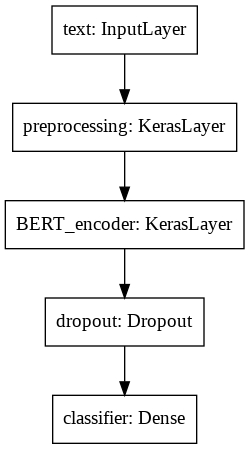

In [18]:
tf.keras.utils.plot_model(classifier_model)

## Model training

이제 전처리 모듈, BERT 인코더, 데이터 및 분류기를 포함하여 모델을 훈련하는 데 필요한 모든 부분이 있습니다.

### Loss function

이것은 이진 분류 문제이고 모델이 확률을 출력하므로 `losses.BinaryCrossentropy` 손실 함수를 사용합니다.


In [19]:
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)
metrics = tf.metrics.BinaryAccuracy()

### Optimizer

미세 조정을 위해 BERT가 원래 훈련된 것과 동일한 최적화 프로그램인 `Adaptive Moments`(Adam)를 사용하겠습니다. 이 옵티마이저는 예측 손실을 최소화하고 [AdamW](https://arxiv.org/abs/1711.05101)라고도 하는 가중치 감쇠(모멘트를 사용하지 않음)로 정규화합니다.

학습률(`init_lr`)의 경우 BERT 사전 학습과 동일한 일정을 사용합니다. 학습 단계의 처음 10%를 `num_warmup_steps`으로 합니다. BERT 논문에 따르면 초기 학습률은 미세 조정을 위해 작게 시작합니다.

In [20]:
epochs = 5
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps)

init_lr = 3e-5
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')
classifier_model.compile(optimizer=optimizer,
                         loss=loss,
                         metrics=metrics)

### BERT 모델 로드 및 학습

훈련 시간은 선택한 BERT 모델의 복잡성에 따라 달라집니다.
약 30 분 소요

In [21]:
import time
s = time.time()
print(f'Training model with {tfhub_handle_encoder}')
history = classifier_model.fit(x=train_ds,
                               validation_data=val_ds,
                               epochs=epochs)
print(time.time() - s)

Training model with https://tfhub.dev/tensorflow/bert_multi_cased_L-12_H-768_A-12/3
Epoch 1/5
625/625 [==============================] - 396s 611ms/step - loss: 0.4722 - binary_accuracy: 0.7473 - val_loss: 0.3830 - val_binary_accuracy: 0.8444
Epoch 2/5
625/625 [==============================] - 377s 603ms/step - loss: 0.2905 - binary_accuracy: 0.8751 - val_loss: 0.3984 - val_binary_accuracy: 0.8556
Epoch 3/5
625/625 [==============================] - 377s 603ms/step - loss: 0.1783 - binary_accuracy: 0.9322 - val_loss: 0.4889 - val_binary_accuracy: 0.8532
Epoch 4/5
625/625 [==============================] - 377s 603ms/step - loss: 0.1116 - binary_accuracy: 0.9622 - val_loss: 0.6459 - val_binary_accuracy: 0.8554
Epoch 5/5
625/625 [==============================] - 377s 603ms/step - loss: 0.0659 - binary_accuracy: 0.9811 - val_loss: 0.7451 - val_binary_accuracy: 0.8564
1902.6922082901


### Evaluate the model


In [22]:
loss, accuracy = classifier_model.evaluate(test_ds)

print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

782/782 [==============================] - 162s 207ms/step - loss: 0.7195 - binary_accuracy: 0.8603
Loss: 0.7195278406143188
Accuracy: 0.8602799773216248


### Plot the accuracy and loss over time

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


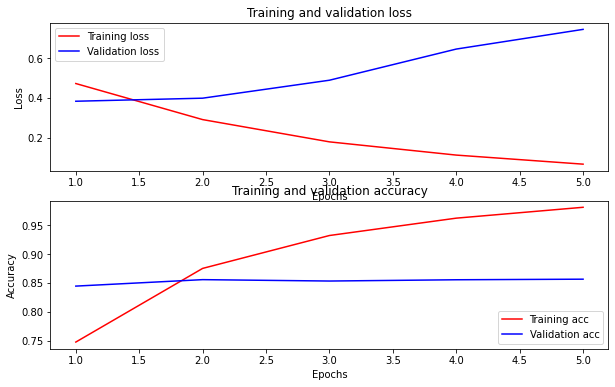

In [23]:
history_dict = history.history
print(history_dict.keys())

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)
fig = plt.figure(figsize=(10, 6))
fig.tight_layout()

plt.subplot(2, 1, 1)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

## Export for inference

In [24]:
dataset_name = 'imdb'
saved_model_path = './{}_bert'.format(dataset_name.replace('/', '_'))

classifier_model.save(saved_model_path, include_optimizer=False)

INFO:tensorflow:Assets written to: ./imdb_bert/assets


INFO:tensorflow:Assets written to: ./imdb_bert/assets


In [25]:
reloaded_model = tf.saved_model.load(saved_model_path)

원하는 문장으로 모델을 테스트할 수 있습니다. 아래의 예제 변수에 추가하기만 하면 됩니다.

In [26]:
def print_my_examples(inputs, results):
  result_for_printing = \
    [f'input: {inputs[i]:<30} : score: {results[i][0]:.6f}'
                         for i in range(len(inputs))]
  print(*result_for_printing, sep='\n')
  print()


examples = [
    'this is such an amazing movie!',  # this is the same sentence tried earlier
    'The movie was great!',
    'The movie was meh.',
    'The movie was okish.',
    'The movie was terrible...'
]

reloaded_results = tf.sigmoid(reloaded_model(tf.constant(examples)))
original_results = tf.sigmoid(classifier_model(tf.constant(examples)))

print('Results from the saved model:')
print_my_examples(examples, reloaded_results)
print('Results from the model in memory:')
print_my_examples(examples, original_results)

Results from the saved model:
input: this is such an amazing movie! : score: 0.999484
input: The movie was great!           : score: 0.999240
input: The movie was meh.             : score: 0.067106
input: The movie was okish.           : score: 0.016092
input: The movie was terrible...      : score: 0.000392

Results from the model in memory:
input: this is such an amazing movie! : score: 0.999484
input: The movie was great!           : score: 0.999240
input: The movie was meh.             : score: 0.067106
input: The movie was okish.           : score: 0.016092
input: The movie was terrible...      : score: 0.000392



[TF Serving](https://www.tensorflow.org/tfx/guide/serving)에서 모델을 사용하려면 명명된 서명 중 하나를 통해 저장된 모델을 호출한다는 점을 기억하세요. Python에서는 다음과 같이 테스트할 수 있습니다.

In [27]:
serving_results = reloaded_model \
            .signatures['serving_default'](tf.constant(examples))

serving_results = tf.sigmoid(serving_results['classifier'])

print_my_examples(examples, serving_results)

input: this is such an amazing movie! : score: 0.999484
input: The movie was great!           : score: 0.999240
input: The movie was meh.             : score: 0.067105
input: The movie was okish.           : score: 0.016092
input: The movie was terrible...      : score: 0.000392



## Next steps

다중 입력을 TPU에서 실행되고 여러 작업을 수행하는 방법을 보여주는 [TPU 튜토리얼에서 BERT를 사용하여 GLUE 작업 해결](https://www.tensorflow.org/text/tutorials/bert_glue)을 시도할 수 있습니다.